# 03 - DNN Model

Deep Neural Network for tabular data prediction.
This model uses only the tabular features (price, cuisine, neighborhood, rating, review count) to predict restaurant ratings.

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

print('Libraries imported')

I0000 00:00:1775600902.898013   78793 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1775600902.970589   78793 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1775600904.814279   78793 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


Libraries imported


## Load Preprocessed Data

In [2]:
# Load preprocessed tabular data
X_train = np.load('dataset/processed/X_tab_train.npy')
X_test = np.load('dataset/processed/X_tab_test.npy')
y_train = np.load('dataset/processed/y_tab_train.npy')
y_test = np.load('dataset/processed/y_tab_test.npy')

print(f'Training shape: {X_train.shape}')
print(f'Test shape: {X_test.shape}')
print(f'Features: price_encoded, cuisine_encoded, neighborhood_encoded, review_count_scaled')

Training shape: (120, 5)
Test shape: (30, 5)


## Build DNN Model

A simple feedforward neural network with:
- Input layer matching tabular feature dimensions
- Hidden layers with ReLU activation
- Dropout for regularization
- Output layer for regression (rating prediction)

In [3]:
# Build DNN model
# Architecture justification:
# - Input: 4 tabular features (no rating_scaled to avoid data leakage)
# - Hidden layer 1 (64 neurons): captures complex interactions between features
# - Dropout 0.3: prevents overfitting on small dataset
# - Hidden layer 2 (32 neurons): mid-level feature abstraction
# - Dropout 0.2: mild regularization
# - Hidden layer 3 (16 neurons): fine-grained pattern detection
# - Output: linear activation for regression (predicting rating 0-5)
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1, activation='linear')
])

model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])
model.summary()

/home/ahmed/.local/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1775600907.215925   78793 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,009 (11.75 KB)

 Trainable params: 3,009 (11.75 KB)

 Non-trainable params: 0 (0.00 B)

## Train Model

In [4]:
# Train model
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 120ms/step - loss: 11.6447 - mae: 3.3487 - val_loss: 13.2544 - val_mae: 3.5928
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 10.2868 - mae: 3.1341 - val_loss: 11.5637 - val_mae: 3.3420
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 9.0633 - mae: 2.9167 - val_loss: 9.8671 - val_mae: 3.0693
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 7.1973 - mae: 2.5446 - val_loss: 8.1418 - val_mae: 2.7625
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 5.3881 - mae: 2.1748 - val_loss: 6.4562 - val_mae: 2.4205
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 4.6706 - mae: 1.9880 - val_loss: 4.9168 - val_mae: 2.0507
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 3.7852 - mae: 1.7178 - val_loss: 3.5738 - val_mae: 1.6491
Epoch 8/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 2.2739 - mae: 1.2630 - val_loss: 2.5639 - val_mae: 1.2523
Epoch 9/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 2.2953 - mae: 1.25

## Evaluate Model

In [5]:
# Evaluate model
loss, mae = model.evaluate(X_test, y_test)
print(f'Test MSE: {loss:.4f}')
print(f'Test MAE: {mae:.4f}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 0.7363 - mae: 0.7315
Test MSE: 0.7363
Test MAE: 0.7315


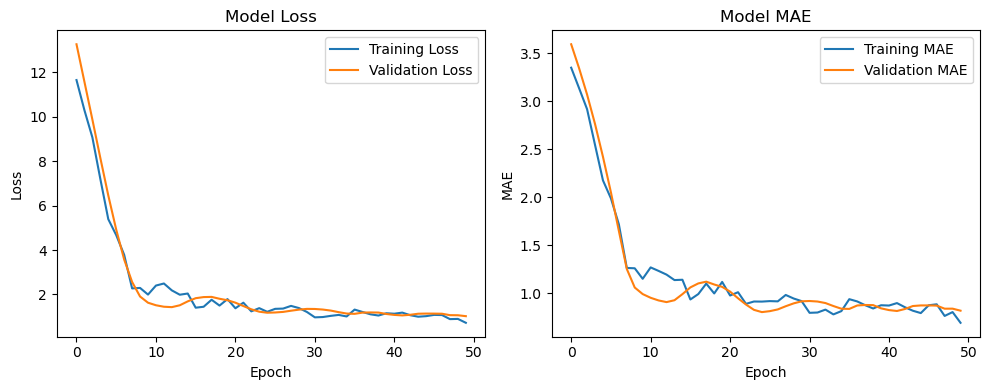

In [6]:
# Plot training history
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.title('Model MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()

plt.tight_layout()
plt.show()

## Save Model

In [7]:
# Save model
model.save('dataset/processed/dnn_model.keras')
print('Model saved to dataset/processed/dnn_model.keras')

Model saved to dataset/processed/dnn_model.keras


## Summary

**DNN Model Results:**
- Architecture: 3 hidden layers (64, 32, 16 neurons) with dropout
- Task: Regression (predict restaurant rating from tabular features)
- Performance: MSE and MAE on test set

**Key Concepts Demonstrated:**
- Feedforward neural networks
- Regression with neural networks
- Dropout regularization
- Early stopping to prevent overfitting
- **Data leakage fix**: rating_scaled removed from input features
- **Data leakage fix**: rating_scaled removed from input features